# Laboratorio 5: Descripción de los datos y preprocesamiento

**Objetivo:** Clasificar si un tweet se refiere a un desastre real (`target = 1`) o no (`target = 0`).

**Este notebook se encarga de:**
1. Cargar y describir el dataset `train.csv`.
2. Explorar cada columna (`id`, `keyword`, `location`, `text`, `target`) para entender su calidad y contenido.
3. Diseñar y aplicar un pipeline de **limpieza y preprocesamiento de texto**.
4. Dejar el dataset limpio (`train_clean.csv`) para reutilizarlo mas adelante.



In [1]:
import re
import string
import html

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import nltk
nltk.download("stopwords", quiet=True)
from nltk.corpus import stopwords

pd.set_option("display.max_colwidth", 120)
sns.set_theme(style="whitegrid")


## 1. Carga de datos

Cargar el archivo `train.csv` descargado de la competencia de Kaggle.


In [2]:
DATA_PATH = "./data/train.csv"
df = pd.read_csv(DATA_PATH)
df.head()


,id,keyword,location,text,target
0,1,NaN,NaN,Our Deeds are the Reason of this #earthquake May ALLAH Forgive us all,1
1,4,NaN,NaN,Forest fire near La Ronge Sask. Canada,1
2,5,NaN,NaN,All residents asked to 'shelter in place' are being notified by officers. No other evacuation or shelter in place or...,1
3,6,NaN,NaN,"13,000 people receive #wildfires evacuation orders in California",1
4,7,NaN,NaN,Just got sent this photo from Ruby #Alaska as smoke from #wildfires pours into a school,1


## 2. Descripción general del dataset

Revisar las dimensiones, tipos de datos y valores nulos por columna. Esto revela información sobre el dataset.


In [3]:
print(f"Filas: {df.shape[0]:,}  |  Columnas: {df.shape[1]}")
df.info()


Filas: 7,613  |  Columnas: 5
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7613 entries, 0 to 7612
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   id        7613 non-null   int64 
 1   keyword   7552 non-null   object
 2   location  5080 non-null   object
 3   text      7613 non-null   object
 4   target    7613 non-null   int64 
dtypes: int64(2), object(3)
memory usage: 297.5+ KB


In [4]:
nulos = df.isnull().sum().to_frame("nulos")
nulos["% del total"] = (nulos["nulos"] / len(df) * 100).round(2)
nulos


,nulos,% del total
id,0,0.00
keyword,61,0.80
location,2533,33.27
text,0,0.00
target,0,0.00


**Análisis:**
- `id`, `text` y `target` no tienen valores nulos, esto indica que son las columnas núcleo del problema.
- `keyword` tiene relativamente pocos nulos con menos del 1%, lo que significa que es utilizable como variable auxiliar.
- `location` tiene una proporción alta de nulos alrededor del 33%, por lo que no será tomada en cuenta para este análisis.


## 3. Análisis de la variable objetivo (`target`)

Se revisa el balance de clases, algo fundamental antes de entrenar cualquier modelo de clasificación,
ya que un desbalance fuerte podría requerir una preparación adicional.


In [5]:
conteo_target = df["target"].value_counts().sort_index()
prop_target = df["target"].value_counts(normalize=True).sort_index() * 100

resumen_target = pd.DataFrame({
    "clase": ["0 = No desastre", "1 = Sí desastre"],
    "n_tweets": conteo_target.values,
    "% del total": prop_target.round(2).values
})
resumen_target


,clase,n_tweets,% del total
0,0 = No desastre,4342,57.03
1,1 = Sí desastre,3271,42.97


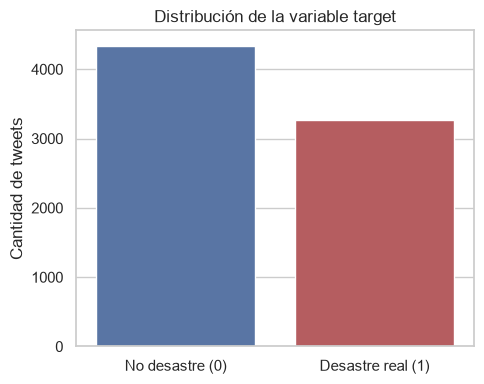

In [6]:
plt.figure(figsize=(5, 4))
sns.countplot(data=df, x="target", hue="target", palette=["#4C72B0", "#C44E52"], legend=False)
plt.xticks([0, 1], ["No desastre (0)", "Desastre real (1)"])
plt.title("Distribución de la variable target")
plt.ylabel("Cantidad de tweets")
plt.xlabel("")
plt.tight_layout()
plt.show()


**Análisis:** 
El dataset está moderadamente desbalanceado, ya que, aproximadamente 57% de los
tweets no hablan de un desastre real y 43% sí. Cabe recalcar que no es un desbalance extremo, por lo que un modelo base de clasificación binaria debería poder entrenarse sin técnicas de
rebalanceo agresivas, aunque es conveniente reportar métricas como precision, recall y F1 además de accuracy al evaluar los modelos. 


## 4. Análisis de la columna `keyword`

`keyword` es una palabra clave asociada al tweet extraída por Twitter a partir de
hashtags o términos de búsqueda. Se revisa cuántas categorías distintas hay y cuáles se asocian
más con tweets de desastre real contra no real.


In [7]:
print("Keywords distintas:", df["keyword"].nunique())
print("Tweets sin keyword:", df["keyword"].isnull().sum())

top_keywords = df["keyword"].value_counts().head(15)
top_keywords


Keywords distintas: 221
Tweets sin keyword: 61


keyword
fatalities     45
deluge         42
armageddon     42
damage         41
body%20bags    41
harm           41
sinking        41
evacuate       40
outbreak       40
fear           40
siren          40
windstorm      40
collided       40
twister        40
hellfire       39
Name: count, dtype: int64

In [20]:
# Keywords con mayor proporción de tweets etiquetados como desastre real (target=1)
keyword_target = (
    df.dropna(subset=["keyword"])
      .groupby("keyword")["target"]
      .agg(["mean", "count"])
      .rename(columns={"mean": "proporcion_desastre", "count": "n_tweets"})
)

print("Top 10 keywords mas asociadas a desastre real:")
display(keyword_target[keyword_target["n_tweets"] >= 10].sort_values("proporcion_desastre", ascending=False).head(10))

print("\nTop 10 keywords menos asociadas a desastre real:")
display(keyword_target[keyword_target["n_tweets"] >= 10].sort_values("proporcion_desastre", ascending=True).head(10))


Top 10 keywords mas asociadas a desastre real:


,proporcion_desastre,n_tweets
keyword,,
debris,1.000000,37
derailment,1.000000,39
wreckage,1.000000,39
outbreak,0.975000,40
oil%20spill,0.973684,38
typhoon,0.973684,38
suicide%20bombing,0.969697,33
suicide%20bomber,0.967742,31
bombing,0.931034,29



Top 10 keywords menos asociadas a desastre real:


,proporcion_desastre,n_tweets
keyword,,
aftershock,0.000000,34
body%20bags,0.024390,41
ruin,0.027027,37
blazing,0.029412,34
body%20bag,0.030303,33
electrocute,0.031250,32
screaming,0.055556,36
traumatised,0.057143,35
panicking,0.060606,33


**Análisis:** 
Hay keywords casi perfectamente predictivas en un sentido como `debris`,
`wreckage`y `derailment` que suelen aparecer casi siempre en tweets de desastre real y otras que 
casi siempre aparecen en tweets que no son de desastre real como `aftershock`, palabras usadas de forma
figurada como `body%20bag` y `ruin`, pero que en Twitter se usan mucho en sentido de humor.
Esto sugiere que `keyword` podría ser una variable predictiva útil para el modelo.


## 5. Análisis de la longitud de los tweets

Se compara la longitud de los tweets entre las dos clases,
para ver si hay una diferencia estructural.


In [9]:
df["n_caracteres"] = df["text"].str.len()
df["n_palabras"] = df["text"].str.split().apply(len)

df.groupby("target")[["n_caracteres", "n_palabras"]].describe().T


target                        0            1
n_caracteres count  4342.000000  3271.000000
             mean     95.706817   108.113421
             std      35.885924    29.309854
             min       7.000000    14.000000
             25%      68.000000    88.000000
             50%     101.000000   115.000000
             75%     130.000000   136.000000
             max     157.000000   151.000000
n_palabras   count  4342.000000  3271.000000
             mean     14.704744    15.167533
             std       6.161564     5.096806
             min       1.000000     2.000000
             25%      10.000000    11.000000
             50%      15.000000    15.000000
             75%      19.000000    19.000000
             max      31.000000    30.000000

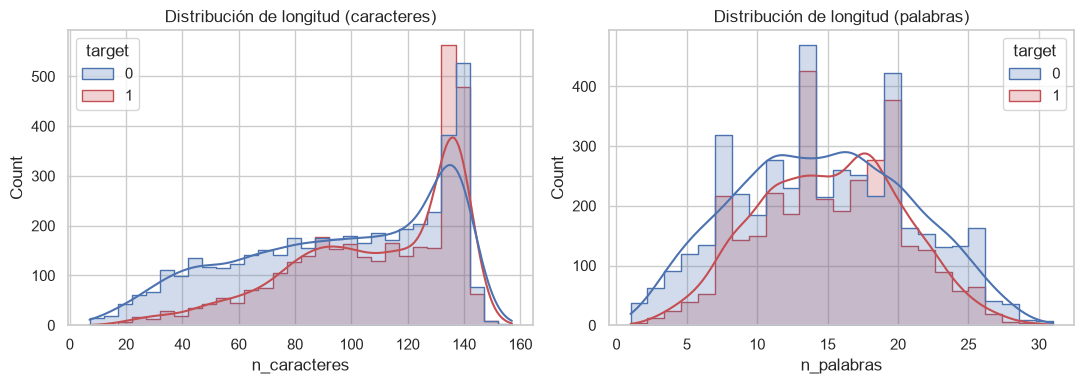

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

sns.histplot(data=df, x="n_caracteres", hue="target", bins=30, kde=True, ax=axes[0],
             palette=["#4C72B0", "#C44E52"], element="step")
axes[0].set_title("Distribución de longitud (caracteres)")

sns.histplot(data=df, x="n_palabras", hue="target", bins=25, kde=True, ax=axes[1],
             palette=["#4C72B0", "#C44E52"], element="step")
axes[1].set_title("Distribución de longitud (palabras)")

plt.tight_layout()
plt.show()


**Análisis:** 
Las distribuciones de longitud son similares entre ambas clases, con una
leve tendencia de los tweets de desastre real a ser un poco más largos. No es una
diferencia relevante, así que la longitud por sí sola no sería una variable fuertemente
discriminante.


## 6. Preprocesamiento y limpieza de texto

Antes de analizar frecuencias de palabras, generar n-gramas o entrenar un modelo, el texto
crudo de Twitter necesita limpieza, ya que contiene URLs, menciones (`@usuario`), hashtags (`#tema`),
entidades HTML `&amp;`, errores de codificación y puntuación o números que
generalmente no aportan valor semántico.


In [11]:
pd.set_option("display.max_colwidth", 200)
df[["text"]].sample(6, random_state=42)


,text
2644,So you have a new weapon that can cause un-imaginable destruction.
2227,The f$&amp;@ing things I do for #GISHWHES Just got soaked in a deluge going for pads and tampons. Thx @mishacollins @/@
5448,DT @georgegalloway: RT @Galloway4Mayor: ÛÏThe CoL police can catch a pickpocket in Liverpool Stree... http://t.co/vXIn1gOq4Q
132,Aftershock back to school kick off was great. I want to thank everyone for making it possible. What a great night.
6845,in response to trauma Children of Addicts develop a defensive self - one that decreases vulnerability. (3
5559,@Calum5SOS you look like you got caught in a rainstorm this is amazing and disgusting at the same time


### 6.1 Problema: caracteres mal codificados

Al revisar tweets al azar se detectaron secuencias como `\x89ÛÒ`, `\x89Ûª` o `åÊ`. Esto ocurre
porque el dataset original tenía texto en UTF-8 que fue re-codificado incorrectamente como Latin-1/CP1252.


In [12]:
patron_mojibake = df["text"].str.contains(r"\\x89|Û|åÊ|åÈ", regex=True, na=False)
print(f"Tweets con artefactos de codificación: {patron_mojibake.sum()} "
      f"({patron_mojibake.mean()*100:.1f}% del total)")
df.loc[patron_mojibake, "text"].head(3).tolist()


Tweets con artefactos de codificación: 658 (8.6% del total)


['Barbados #Bridgetown JAMAICA \x89ÛÒ Two cars set ablaze: SANTA CRUZ \x89ÛÓ Head of the St Elizabeth Police Superintende...  http://t.co/wDUEaj8Q4J',
 'SANTA CRUZ \x89ÛÓ Head of the St Elizabeth Police Superintendent Lanford Salmon has r ... - http://t.co/vplR5Hka2u http://t.co/SxHW2TNNLf',
 'Police: Arsonist Deliberately Set Black Church In North CarolinaåÊAblaze http://t.co/pcXarbH9An']

### 6.2 Diseño del pipeline de limpieza

Se aplican los pasos sugeridos, en un orden pensado para no generar efectos
secundarios:

1. **Corregir artefactos de codificación** (`\x89Û_`, `åÊ`, etc.)
2. **Quitar URLs** (`http://...`, `https://...`, `www...`)
3. **Decodificar entidades HTML** (`&amp;` → `&`, etc.)
4. **Quitar menciones** (`@usuario`)
5. **Procesar hashtags** (`#earthquake` → `earthquake`)
6. **Convertir a minúsculas**
7. **Quitar signos de puntuación y caracteres especiales**
8. **Quitar números, con una excepción explícita: `911`**. 
9. **Tokenización**
10. **Quitar *stopwords***


In [13]:
# Verificación explícita de emojis Unicode reales en el texto crudo
patron_emoji = re.compile(
    "["
    "\U0001F600-\U0001F64F"  # emoticones
    "\U0001F300-\U0001F5FF"  # símbolos y pictogramas
    "\U0001F680-\U0001F6FF"  # transporte y mapas
    "\U0001F900-\U0001F9FF"  # símbolos suplementarios
    "\U00002600-\U000026FF"  # símbolos varios
    "\U00002700-\U000027BF"  # dingbats
    "]+", flags=re.UNICODE
)

tweets_con_emoji = df["text"].apply(lambda t: len(patron_emoji.findall(t)) > 0).sum()
print(f"Tweets con emojis Unicode reales detectados: {tweets_con_emoji}")


Tweets con emojis Unicode reales detectados: 0


In [14]:
stop_words_en = set(stopwords.words("english"))
print(f"Número de stopwords en inglés (nltk): {len(stop_words_en)}")
list(stop_words_en)[:15]


Número de stopwords en inglés (nltk): 198


['any',
 'itself',
 "shan't",
 'down',
 'over',
 'here',
 "weren't",
 'from',
 'themselves',
 "mightn't",
 'she',
 're',
 "should've",
 "they're",
 'some']

In [15]:
def corregir_mojibake(texto):
    # Corrige/elimina artefactos de re-codificación típicos de este dataset
    texto = re.sub(r"\x89Û_", "'", texto)
    texto = re.sub(r"\x89Û[ÒÓªÏ]", " ", texto)
    texto = re.sub(r"åÊ|åÈ", " ", texto)
    texto = re.sub(r"[\x80-\x9f]", " ", texto)
    return texto


def quitar_urls(texto):
    return re.sub(r"https?://\S+|www\.\S+", " ", texto)


def quitar_menciones(texto):
    return re.sub(r"@\w+", " ", texto)


def procesar_hashtags(texto):
    # Quita el símbolo '#' pero conserva la palabra, ya que suele ser informativa
    return re.sub(r"#(\w+)", r"\1", texto)


def quitar_numeros_excepto_911(texto):
    tokens = texto.split()
    tokens = [t for t in tokens if not (t.isdigit() and t != "911")]
    return " ".join(tokens)


def limpiar_tweet(texto):
    texto = corregir_mojibake(texto)
    texto = quitar_urls(texto)
    texto = html.unescape(texto)
    texto = quitar_menciones(texto)
    texto = procesar_hashtags(texto)
    texto = texto.lower()
    texto = re.sub(f"[{re.escape(string.punctuation)}]", " ", texto)
    texto = quitar_numeros_excepto_911(texto)
    texto = re.sub(r"\s+", " ", texto).strip()

    tokens = [w for w in texto.split() if w not in stop_words_en and len(w) > 1]
    return " ".join(tokens)


# Ejemplo paso a paso sobre un tweet real del dataset
ejemplo = df.loc[df["text"].str.contains("earthquake", case=False), "text"].iloc[0]
print("Original      :", ejemplo)
print("Sin URLs      :", quitar_urls(ejemplo))
print("Sin menciones :", quitar_menciones(quitar_urls(ejemplo)))
print("Limpio final  :", limpiar_tweet(ejemplo))


Original      : Our Deeds are the Reason of this #earthquake May ALLAH Forgive us all
Sin URLs      : Our Deeds are the Reason of this #earthquake May ALLAH Forgive us all
Sin menciones : Our Deeds are the Reason of this #earthquake May ALLAH Forgive us all
Limpio final  : deeds reason earthquake may allah forgive us


In [16]:
df["clean_text"] = df["text"].apply(limpiar_tweet)
df[["text", "clean_text"]].sample(8, random_state=7)


,text,clean_text
6106,If there's a chance will get a gander of the sinking ship that is #TNA too. Can't help but appease my morbid curiosity. #DestinationIMPACT,chance get gander sinking ship tna help appease morbid curiosity destinationimpact
5025,2 great new recipes; mudslide cake and so sorry stew! #GBBO,great new recipes mudslide cake sorry stew gbbo
7022,#breaking #news Global precipitation measurement satellite captures 3-D image of Typhoon Soudelor - @NASAHurricane http://t.co/20DNcthr4D,breaking news global precipitation measurement satellite captures image typhoon soudelor
2331,EPA begins demolition of homes in toxic area #Buffalo - http://t.co/noRkXBRS6G,epa begins demolition homes toxic area buffalo
3354,KATUNews: #SR14 remains closed as brush fire burns 1700 acres: http://t.co/QposKp3MWj #LiveOnK2 http://t.co/mTQjsvupwy,katunews sr14 remains closed brush fire burns acres liveonk2
6117,Spent too many hours sinking into the wonderfully created worlds of Mafia and Mafia II in my life. Excited for another installment.,spent many hours sinking wonderfully created worlds mafia mafia ii life excited another installment
2258,Businesses are deluged with invoices. Make yours stand oup with colour or shame and it's likely to rise to the top of the pay' pile.,businesses deluged invoices make stand oup colour shame likely rise top pay pile
2801,@Hollyorange8 my day has been a disaster of emotions,day disaster emotions


### 6.3 Validación del preprocesamiento

Antes de continuar, se debe revisar que la limpieza no haya generado efectos indeseados, como tweets que
quedan vacíos y la reducción de longitud promedio.


In [17]:
df["clean_n_palabras"] = df["clean_text"].str.split().apply(len)

vacios = df[df["clean_n_palabras"] == 0]
print(f"Tweets que quedaron vacíos tras la limpieza: {len(vacios)}")
vacios[["text", "target"]]


Tweets que quedaron vacíos tras la limpieza: 2


,text,target
4497,@Hurricane_Dame ???????? I don't have them they out here,1
6766,@Ayshun_Tornado then don't,0


Solo un puñado de tweets queda vacío tras la limpieza ya que eran mensajes que eran básicamente una mención
a otro usuario más una o dos *stopwords*. Esto representa un volumen insignificante frente a las 7,600 filas del dataset, por lo que se decide **conservarlos**
tal cual en vez de eliminarlos, ya que descartar filas cambiaría el balance de clases y el vectorizador simplemente los representará como un vector de ceros.


In [18]:
comparacion_longitud = pd.DataFrame({
    "promedio_palabras_original": [df["n_palabras"].mean()],
    "promedio_palabras_limpio": [df["clean_n_palabras"].mean()],
    "reduccion_%": [(1 - df["clean_n_palabras"].mean() / df["n_palabras"].mean()) * 100]
}).round(2)
comparacion_longitud


,promedio_palabras_original,promedio_palabras_limpio,reduccion_%
0,14.9,8.62,42.17


La limpieza reduce la longitud promedio de los tweets en más de un tercio, principalmente por la
eliminación de *stopwords*, menciones y URLs.


## 7. Guardado del dataset preprocesado

Guardamos el dataset con la columna `clean_text` (y las columnas auxiliares calculadas) en un nuevo
CSV, que será el punto de partida del **Notebook 2** (frecuencias, n-gramas, nube de palabras y
modelo preliminar de clasificación), evitando repetir todo el preprocesamiento.


In [22]:
columnas_finales = ["id", "keyword", "location", "text", "clean_text",
                    "n_caracteres", "n_palabras", "clean_n_palabras", "target"]
df[columnas_finales].to_csv("./data/train_clean.csv", index=False)
print("Archivo './data/train_clean.csv' guardado con", df.shape[0], "filas.")


Archivo './data/train_clean.csv' guardado con 7613 filas.


## 8. Resumen del preprocesamiento

- El dataset tiene **7,613 tweets**, con un desbalance moderado de clases (**57% no-desastre / 43%
  desastre real**).
- `keyword` es una variable con potencial predictivo (algunas keywords están casi perfectamente
  asociadas a una clase); `location` es demasiado libre/sucia para usarse sin un trabajo de
  normalización adicional, por lo que se deja fuera del alcance de esta fase.
- El texto crudo requería limpieza en varios frentes: URLs, menciones, hashtags, entidades HTML,
  artefactos de codificación (*mojibake*, ~8.6% de los tweets) y *stopwords*.
- Se decidió **conservar el token `911`** por su fuerte carga semántica relacionada con
  emergencias, a diferencia del resto de números.
- No se detectaron emoticones Unicode reales en el dataset (se verificó explícitamente).
- El dataset limpio (`train_clean.csv`) queda listo para el análisis de frecuencias, n-gramas, nube
  de palabras y el modelo preliminar, que se desarrollan en el **Notebook 02**.
